In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({'font.size':14})
import matplotlib.colors as colors
#import matplotlib.colors as mcolors
import matplotlib.cm as cm
from matplotlib.cm import GnBu, viridis
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)


In [133]:
sim_name = "fargo_nu3b"
results_dir = "/projects/b1094/jding/fargo/outputs/" + sim_name + "/"
Sigma0 = 6.4e-4

# load in sim parameters
params = {}
with open(results_dir + "variables.par") as f:
    for line in f:
       (key, val) = line.split()
       params[key] = val

# physical parameters
alpha = (float) (params['ALPHA'])
cs = (float) (params['ASPECTRATIO'])
Mp = 1.e-3
THICKNESSSMOOTHING = (float) (params['THICKNESSSMOOTHING'])
b = cs*THICKNESSSMOOTHING

# note: this excludes ghost zones
N_R = (int) (params['NY'])
N_phi = (int) (params['NX'])

i = str(100) # output number
den = np.fromfile(results_dir + "gasdens"+i+".dat").reshape(N_R,N_phi)
# velocities in simulation frame
vR = np.fromfile(results_dir + "gasvy"+i+".dat").reshape(N_R,N_phi)
vphi = np.fromfile(results_dir + "gasvx"+i+".dat").reshape(N_R,N_phi)

DT = (float) (params['DT'])
# number of DTs between scalar field outputs
Ninterm = (int) (params['NINTERM'])
t_sim = int(i) * Ninterm * DT

In [17]:
## loads 135 R coordinates (face-centered)
# Rs = np.loadtxt(results_dir + "domain_y.dat", dtype=float)

In [88]:
# load in domain
Rmin = (float) (params['YMIN'])
Rmax = (float) (params['YMAX'])
phiMin = (float) (params['XMIN'])
phiMax = (float) (params['XMAX'])

Rs = np.loadtxt(results_dir + "domain_y.dat")
phis = np.loadtxt(results_dir + "domain_x.dat")
# exclude ghost zones and outermost coordinate
Rs = Rs[3:-4] 
phis = phis[:-1]
#Rs = np.linspace(Rmin, Rmax, num=N_R)
#phis = np.linspace(phiMin, phiMax, num=N_phi)

In [89]:
phis.shape

(384,)

In [107]:
den

array([[3.83786517e-03, 3.83786516e-03, 3.83786514e-03, ...,
        3.83786520e-03, 3.83786519e-03, 3.83786519e-03],
       [3.72674205e-03, 3.72674205e-03, 3.72674204e-03, ...,
        3.72674206e-03, 3.72674206e-03, 3.72674205e-03],
       [3.61885205e-03, 3.61885204e-03, 3.61885203e-03, ...,
        3.61885206e-03, 3.61885206e-03, 3.61885205e-03],
       ...,
       [9.75581673e-05, 9.75581642e-05, 9.75581610e-05, ...,
        9.75581760e-05, 9.75581732e-05, 9.75581703e-05],
       [9.47338334e-05, 9.47338307e-05, 9.47338279e-05, ...,
        9.47338410e-05, 9.47338385e-05, 9.47338360e-05],
       [9.19813962e-05, 9.19813880e-05, 9.19813794e-05, ...,
        9.19814188e-05, 9.19814116e-05, 9.19814041e-05]])

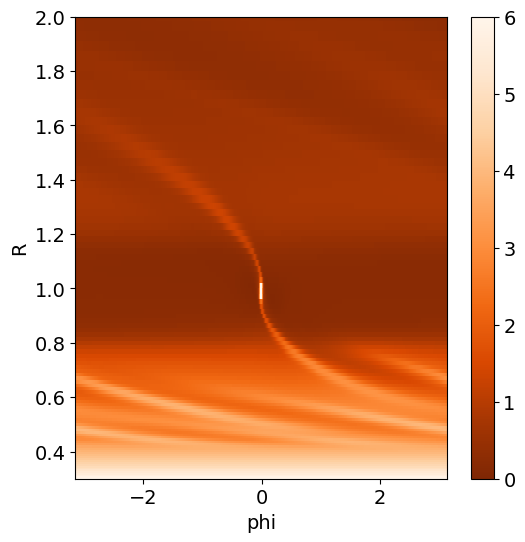

In [135]:
plt.figure(figsize=(6,6))
plt.pcolormesh(phis,Rs,den/Sigma0, vmin=0, vmax=6, \
               cmap=cm.Oranges_r)
plt.colorbar()

plt.xlabel("phi")
plt.ylabel("R")
plt.ylim(0.3,2.)
label = r"$\Sigma/\Sigma_0$"

plt.show()

# Plotting $t_\text{ex}$ and $t_\text{dep}$ (circa 10/8/2026)

Following Dempsey+ 2020's definitions, let's plot the excitation torque density $t_\text{ex}$ and deposition torque density $t_\text{dep}$.

## functions

### numerical derivatives

In [35]:
def derivative(f, x):
    '''
    Returns first derivative of f(x) with respect to the domain x.

    '''
    
    # return scipy.differentiate.derivative(f, x)

    derivs = np.zeros(shape=f.shape)

    # handle boundaries
    derivs[0] = (f[1] - f[0]) / (x[1] - x[0])
    derivs[-1] = (f[-1] - f[-2]) / (x[-1] - x[-2])

    # central difference method
    for i in range(1, len(x)-1):
        derivs[i] = (f[i+1] - f[i-1]) / (x[i+1] - x[i-1])

    return derivs


def p_derivative(f, x, axis):
    '''
    Returns the first partial derivative of f(R,phi) in the R (axis=0)
    or phi (axis=1) direction. x is the domain over which
    the derivative is taken.

    '''

    # return scipy.differentiate.derivative(f, x)
    derivs = np.zeros(shape=f.shape)
    assert ((axis == 0 and len(x) == f.shape[0]) or \
            (axis == 1 and len(x) == f.shape[1])) 

    if axis==0:
        # handle boundaries
        derivs[0,:] = (f[1,:] - f[0,:]) / (x[1] - x[0])
        derivs[-1,:] = (f[-1,:] - f[-2,:]) / (x[-1] - x[-2])
        # central difference method
        for i in range(1, len(x)-1):
            derivs[i,:] = (f[i+1,:] - f[i-1,:]) / (x[i+1] - x[i-1])
    else:
        # handle boundaries (phi is periodic)
        derivs[:,0] = (f[:,1] - f[:,-1]) / (x[1] - x[-1])
        derivs[:,-1] = (f[:,0] - f[:,-2]) / (x[0] - x[-2])
        # central difference method
        for i in range(1, len(x)-1):
            derivs[:,i] = (f[:,i+1] - f[:,i-1]) / (x[i+1] - x[i-1])

    return derivs

### avg and wave component

In [5]:
def az_avg(arr):
    '''
    Given a 2D array (arr) whose first index corresponds to R
    and second index corresponds to phi, compute the azimuthal
    average. (phi must be uniformly spaced.)
    
    '''

    # equivalent to arr_i * dphi_i / (N*dphi)
    # since dphi_i = dphi for uniform spacing
    N_phi = arr.shape[1]
    return np.sum(arr, axis=1) / N_phi

def wave_comp(arr):
    '''
    Given a 2D array (arr) whose first index corresponds to R
    and second index corresponds to phi, compute its wave
    component. (phi must be uniformly spaced.)
    
    '''

    return arr - az_avg(arr)[:,None]

### Fourier coefficient and component

In [7]:
def get_Fourier_coeff(arr, phis, m):
    '''
    Given a 2D array (arr) whose first index corresponds to R
    and second index corresponds to phi, compute the 
    m-th Fourier coefficient with respect to phi.
    (This is a Fourier transform with a complex exponential basis.)

    ``phis'' is the array of phi coordinates. It must:
    1. Be either 1D or 2D (and the second index should correspond to 
    the phi axis)
    2. Span from 0 to 2pi and be uniformly spaced. Furthermore,
    the spacing must satisfy 2pi/dphi = N_phi. (This is how Athena++
    spaces phi.)

    '''

    N_R = arr.shape[0]
    N_phi = arr.shape[1]
    # if phis is 1D, expand to 2D (with 2nd index corresponding to phi axis)
    if (len(phis.shape) == 1):
        phis = np.reshape(phis, shape=(1,N_phi))
        phis = np.repeat(phis, N_R, axis=0)
    # if the input array is 3D, flatten the z axis
    if (len(arr.shape) == 3):
        arr = np.squeeze(arr, axis=2)

    # coeff = 1/(2*pi) * \int f(r,phi)exp(-i*m*phi)dphi
    exps = np.exp(-1.j * m * phis)
    integrand = np.multiply(arr, exps)
    # asssume phis are uniformly spaced
    dphi = phis[0, 1] - phis[0, 0]
    coeff = 1./(2*np.pi) * np.sum(integrand*dphi, axis=1)
    return coeff

def get_Fourier_comp(arr, phis, m):
    '''
    Given a 2D array (arr) whose first index corresponds to R
    and second index corresponds to phi, compute the 
    m-th Fourier component with respect to phi.
    (This is a Fourier transform with a complex exponential basis.)

    The component equals Real[X_m * exp(i*m*phi)], where 
    X_m is the Fourier coefficient. 
    
    '''
    
    coeff = get_Fourier_coeff(arr, phis, m) # shape (N_R,)
    exp_term = np.exp(1.j * m * phis) # shape (N_phi,)
    comp = coeff[:,None] * exp_term[None, :] # shape (N_R,N_phi)
    
    return np.real(comp)

### t_ex and t_dep

In [121]:
def t_ex(den, rad_app, phi_app):
    '''
    Calculate the excitation torque density (t_ex) as a function of R.

    rad_app is the R domain, and phi_app is the phi domain.
    den is the array containing the surface density values.

    NOTE: For a corotating reference frame, the planet is always at phi=0, 
    so we don't need the simulation time to know the planet's
    azimuthal coordinate.
    
    '''

    N_R = len(rad_app)
    N_phi = len(phi_app)
    # define 2D coord arrays to allow for matrix multiplication
    rad_2d = rad_app[:,None]
    phi_2d = phi_app[None,:]

    assert (den.shape[0] == N_R)
    assert (den.shape[1] == N_phi)
    #den = np.squeeze(den, axis=2)
    
    # step 1: calculate Sigma'(R, phi)
    Sig_prime = wave_comp(den)
    ## subtract out m = -1,1 components from Sigma
    Sig_1 = get_Fourier_comp(Sig_prime, phi_app, m=1)
    Sig_1b = get_Fourier_comp(Sig_prime, phi_app, m=-1)
    Sig_prime -= (Sig_1 + Sig_1b)
    # Sig_2 = get_Fourier_comp(Sig_prime, phi_app, m=2)
    # Sig_2b = get_Fourier_comp(Sig_prime, phi_app, m=-2)
    # Sig_prime -= (Sig_2 + Sig_2b)
    
    # step 2: calculate dPhi'/dphi (R,phi)
    phi_p = 0. # 0 in corotating frame
    dPhi_dphi = Mp*rad_2d*np.sin(phi_2d - phi_p) # size is (N_R,N_phi)
    # b is softening radius
    dPhi_dphi /= np.pow(rad_2d**2 + 1. + b**2 - 
        2*rad_2d*np.cos(phi_2d - phi_p), 3/2)
    ## subtract out m = -1,1 components from dPhi/dphi
    dPhi_dphi_1 = get_Fourier_comp(dPhi_dphi, phi_app, m=1)
    dPhi_dphi_1b = get_Fourier_comp(dPhi_dphi, phi_app, m=-1)
    dPhi_dphi -= (dPhi_dphi_1 + dPhi_dphi_1b)
    # dPhi_dphi_2 = get_Fourier_comp(dPhi_dphi, phi_app, m=2)
    # dPhi_dphi_2b = get_Fourier_comp(dPhi_dphi, phi_app, m=-2)
    # dPhi_dphi -= (dPhi_dphi_2 + dPhi_dphi_2b)
    # debugging
    #dPhi_dphi_global = dPhi_dphi + coeff[:,None]*np.cos(phi_app[None,:])
    #print(coeff)
    
    # step 3: calculate azimuthal average of Sigma' * dPhi'/dphi
    #print("dPhi_dphi.shape:", dPhi_dphi.shape)
    X_avg = az_avg(np.multiply(Sig_prime, dPhi_dphi))
    
    # step 4: return -2pi * R*(above quantity)
    return -2*np.pi * rad_app * X_avg#, dPhi_dphi_global

def t_dep(den, vR, vphi, rad_app, phi_app):
    '''
    Calculate the deposition torque density (t_dep) as a function of R.
    See Eq. 50 in Dempsey+ 2020.

    rad_app is the R domain, and phi_app is the phi domain.
    den is the 2D array containing the surface density values; 
    similarly, vR contains radial velocities and vphi contains 
    azimuthal velocities.
    
    '''

    N_R = len(rad_app)
    N_phi = len(phi_app)
    # define 2D coord arrays to allow for matrix multiplication
    rad_2d = rad_app[:,None]
    phi_2d = phi_app[None,:]

    assert (den.shape[0] == N_R)
    assert (den.shape[1] == N_phi)

    # simulation quantities
    Sig_avg = az_avg(den)
    Sig_prime = wave_comp(den)
    vR_prime = wave_comp(vR)
    # ell is specific ang. mom. (ell=r*vphi)
    ell = rad_2d*vphi
    ell_avg = az_avg(ell)
    ell_prime = wave_comp(ell)
    # pressure + viscous stress terms
    P = den * cs**2
    # nu = alpha*cs*H
    nu = alpha * cs**2 * rad_app**(3/2)
    S_rphi = \
        rad_2d*p_derivative(vphi/rad_2d, rad_app, axis=0) \
        + (1/rad_2d) * p_derivative(vR,phi_app, axis=1)
    S_phiphi = 2/rad_2d * (vR + p_derivative(vphi,phi_app, axis=1)) -\
            (2/3)/rad_2d * p_derivative(vphi,phi_app, axis=1)
    
    f = -P + nu[:,None]*np.multiply(S_phiphi,den)

    term1 = az_avg(np.multiply(Sig_prime,vR_prime))
    term1 = np.multiply(term1, derivative(ell_avg, rad_app))
    term2b = az_avg(np.multiply(vR_prime, \
                        p_derivative(ell_prime,rad_app,axis=0)))
    term2 = -np.multiply(Sig_avg, term2b)
    term3a = Sig_prime/Sig_avg[:,None]
    term3b = p_derivative(f, phi_app, axis=1)
    term3 = -az_avg(np.multiply(term3a, term3b))
    term4a = Sig_prime/Sig_avg[:,None] * (1/rad_2d)
    term4b = p_derivative(rad_2d**2 * nu[:,None] * \
                np.multiply(den,S_rphi), rad_app, axis=0)
    term4 = -az_avg(np.multiply(term4a, term4b))
    
    return 2*np.pi * rad_app * (term1 + term2 + term3 + term4)

In [98]:
t_ex(den, Rs, phis)
#t_dep(den, vR, vphi, Rs, phis)

dPhi_dphi.shape: (128, 384)


array([ 2.57110260e-12,  5.81006693e-14, -1.55503666e-15,  1.59528129e-14,
        4.85233849e-14,  1.04975235e-13,  2.03924181e-13,  3.81136774e-13,
        7.08445683e-13,  1.33786302e-12,  2.60836844e-12,  5.26270167e-12,
        1.01714499e-11,  1.32647944e-11,  3.94387667e-11,  9.65344101e-10,
        8.28924163e-09,  2.98412291e-08,  4.45876236e-08,  1.15478560e-09,
       -8.75331714e-08, -1.43215778e-07, -1.39791657e-07, -9.32357443e-08,
       -4.16073490e-08, -9.06656393e-10,  5.98163281e-08,  1.59649007e-07,
        2.63077199e-07,  3.07233994e-07,  2.58362345e-07,  1.23385628e-07,
       -5.52105006e-08, -2.05169102e-07, -2.55110241e-07, -1.84264840e-07,
       -6.49064484e-08,  1.58650367e-08,  3.49650401e-08,  1.51578758e-08,
       -1.71960405e-08, -4.80343373e-08, -7.26254225e-08, -8.93399911e-08,
       -9.93407352e-08, -1.09081496e-07, -1.28194829e-07, -1.69366561e-07,
       -2.44956030e-07, -3.56314978e-07, -5.00631877e-07, -6.61690250e-07,
       -8.22351489e-07, -

## test Fourier coefficient function

[1.06018489e-16+0.j 1.06018489e-16+0.j 1.06018489e-16+0.j
 1.06018489e-16+0.j 1.06018489e-16+0.j 1.06018489e-16+0.j
 1.06018489e-16+0.j 1.06018489e-16+0.j 1.06018489e-16+0.j
 1.06018489e-16+0.j]
r = 0.519134857338312


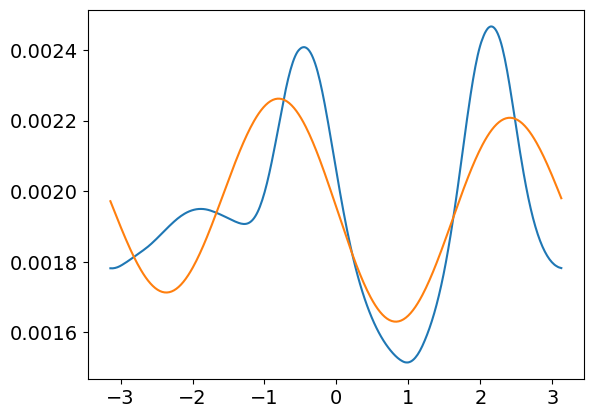

In [104]:
# test Fourier coefficient function
phis_temp = np.linspace(-np.pi, np.pi, 10, endpoint=False)
arr = 3*np.cos(phis_temp[None,:]+0.4)
arr = np.repeat(arr,5, axis=0)
coeff = get_Fourier_coeff(arr, phis_temp, 0)
reconstructed = coeff[:,None] * np.exp(1.j*0*phis_temp[None,:])
print(reconstructed[0,:])
#print("arr minus coeff*cos(phi):")
#print(arr[:,] - coeff*np.cos(phis_temp[None,:]))

## test on density field
ind = 28
print("r =", Rs[ind])

temp = den # np.ones(shape=den.shape)*np.cos(phis[None,:])  # np.copy(den)

den_0 = get_Fourier_comp(temp, phis, m=0)
den_1 = get_Fourier_comp(temp, phis, m=1)
den_1b = get_Fourier_comp(temp, phis, m=-1)
den_2 = get_Fourier_comp(temp, phis, m=2)
den_2b = get_Fourier_comp(temp, phis, m=-2)

## test m=1,-1 components
# temp2 = np.cos(phis[None,:] - 0.3)
# temp2 = np.repeat(temp2,5, axis=0)
# temp2_1 = get_Fourier_comp(temp2, phis, m=1)
# temp2_1b = get_Fourier_comp(temp2, phis, m=-1)

# ind = 3
# plt.plot(phis, temp2[ind,:])
# plt.plot(phis, temp2[ind,:] - temp2_1[ind,:] - 
#         0*temp2_1b[ind,:])

# coeff = get_Fourier_coeff(temp, phis, m=3)
# den_3 = coeff[:,None]*np.cos(3*phis[None,:])
# coeff = get_Fourier_coeff(temp, phis, m=4)
# den_4 = coeff[:,None]*np.cos(4*phis[None,:])
#print(coeff)

plt.plot(phis, temp[ind,:])
plt.plot(phis, den_0[ind,:]+den_1[ind,:]+den_1b[ind,:] \
                   +den_2[ind,:]+den_2b[ind,:])
#plt.plot(phis, 10*den_1[ind,:])
#plt.plot(phis, temp[ind,:] - den_2[ind,:])

## plot torque densities
This plot is based on Figure 5 in Dempsey+ 2020.

### get Mdot

In [83]:
# radial index of planet
i_p = (np.abs(Rs - 1)).argmin()
# Mdot at the planet (not necessarily in VSS)
Mdots = np.sum(np.multiply(den,vR) * Rs[:,None], axis=1)

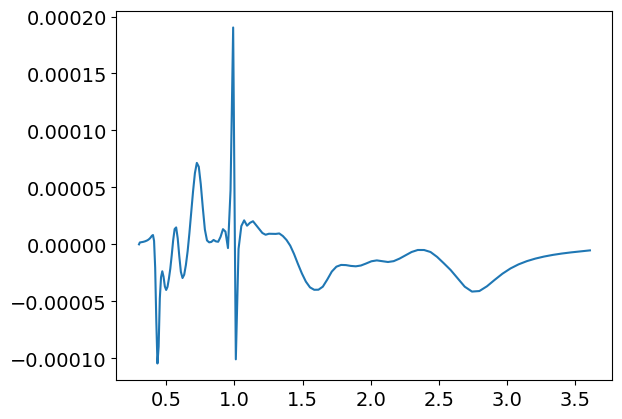

In [93]:
plt.plot(Rs, Mdots)

### plot tex, tdep

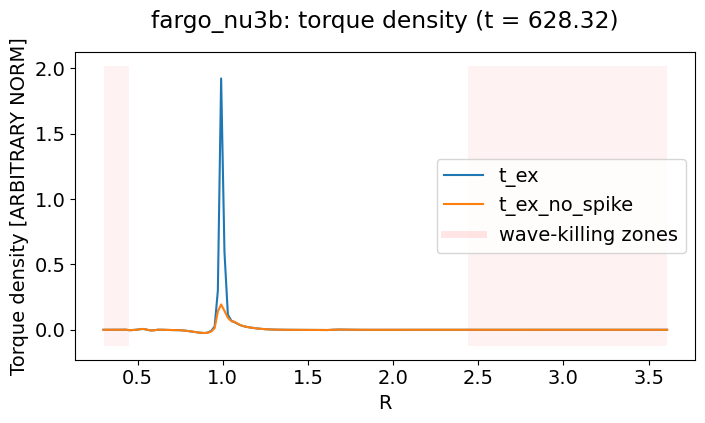

In [143]:
fig, ax = plt.subplots(figsize=(8, 4))

# accretion torque (the negative sign serves to 
# match Adam's convention that Mdot > 0)
# furthermore, ell_p = (rv_phi)_p = r^(1/2) = 1
Mdot_const = -.5e-4 # arbitrary
Mdot_ell_p = -Mdot_const*1.**(1/2)

# crudely+artificially remove spike around planet
den_no_spike = np.copy(den)
den_no_spike[:,191] = den_no_spike[:,190]
den_no_spike[:,192] = den_no_spike[:,193]

t_exs = t_ex(den, Rs, phis)
t_exs_no_spike = t_ex(den_no_spike, Rs, phis)
#t_deps = t_dep(den, vR, vphi, Rs, phis)

#coeff = get_Fourier_coeff(t_exs, phis, m=1) # shape is (N_R,)
#dPhi_dphi -= coeff[:,None]*np.cos(phis[None,:])

plt.plot(Rs, t_exs/Mdot_ell_p, label="t_ex")
plt.plot(Rs, t_exs_no_spike/Mdot_ell_p, label="t_ex_no_spike")
#plt.plot(Rs, t_deps/Mdot_ell_p, label="t_dep")

plt.xlabel("R")
plt.ylabel(r"Torque density [ARBITRARY NORM]") # \, \, [\dot{M} \ell_p \text{, where } \dot{M}>0]$")
#plt.xlim(0.3, 2.4)
#plt.ylim(-0.05, 0.05)

#plt.ticklabel_format(axis='y', style='sci', scilimits=(-3,-3))

# plot wave-killing zones
use_wk = True
if use_wk:
    r_in = 0.3 # 0.4 # 0.5
    r_out = 3.68
    r_iwkz = 0.46 # 0.46 # 0.5 # 0.7
    r_owkz = 2.4 # 3.0 # 2.1 # 1.6
    
    # locations of wave-killing zones
    where = ((Rs > r_in) & (Rs < r_iwkz)) | \
                ((Rs > r_owkz) & (Rs < r_out))
    
    plt.fill_between(Rs, ax.get_ylim()[0], ax.get_ylim()[1], 
                where = where, facecolor='red', alpha=0.05)
    
    plt.plot([],[],color='red',linewidth=5, alpha=0.1, label='wave-killing zones')

plt.title(sim_name + \
    ": torque density (t = {t_sim:.2f})".format(t_sim=t_sim),
         y=1.05)
plt.legend()
plt.show()

In [72]:
DeltaT_ex = np.trapezoid(t_exs, Rs)
DeltaT_dep = np.trapezoid(t_deps, Rs)

In [73]:
DeltaT_dep

np.float64(-7.418527937237624e-06)

# Old plots (replicating de Val-Borro+ 2006 circa 8/6/2026)

## phi on y-axis, R on x-axis (like de Val-Borro+ 2006, Fig 10)

ValueError: 'x' values must be equally spaced

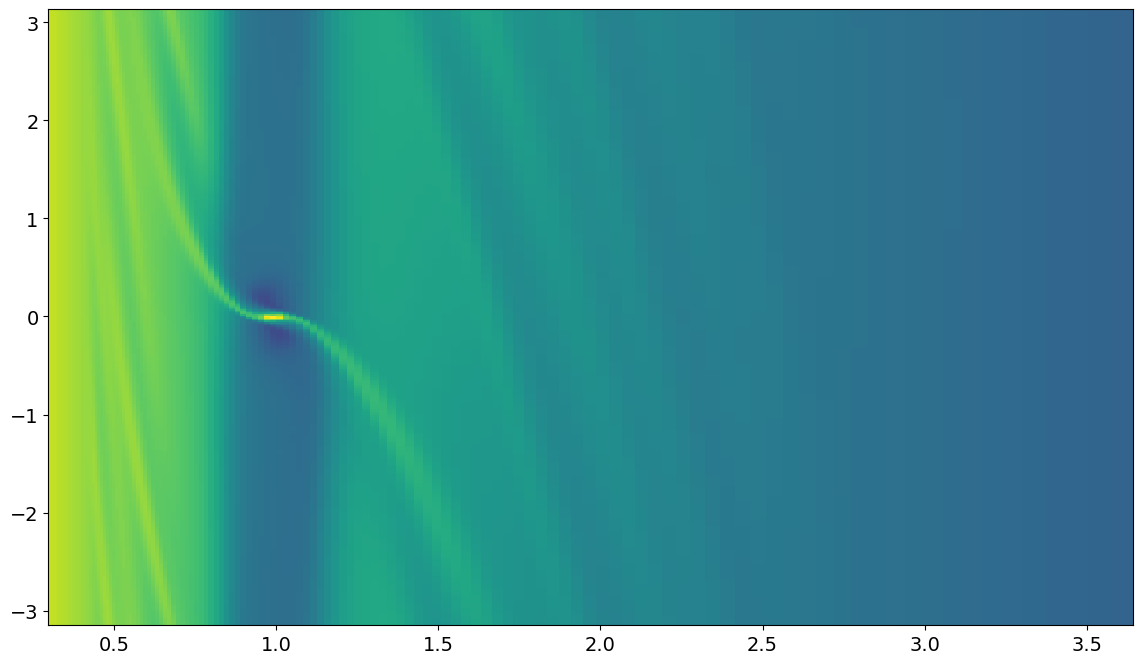

In [35]:
t_sim = 100*6.28 # ath_data['Time']

#### Read in domain ####
d_rad = Rs[1] - Rs[0]
d_phi = phis[1] - phis[0]
rad_3d, phi_3d = np.meshgrid(Rs, phis, indexing='ij')

### make figure
fig, ax = plt.subplots(1, figsize=(14,8))

# normalize Sigma by azimuthally-averaged Sigma (NOT what de Val-Borro does)
# Sigma_integrand = den*d_phi
# Sigma_avg = np.sum(Sigma_integrand,axis=1)/(2*np.pi)
# Sigma_normeds = den/Sigma_avg.reshape(len(Sigma_avg),1)

# normalize Sigma by Sigma_ss (not what de Val-Borro does?)
Sigma_normeds = den / np.reshape(Sigma0*Rs**(-1.5), (len(Rs),1))

# plot normalized sigma
kws = {'cmap': 'viridis', \
       'norm': mcolors.LogNorm(vmin=10**(-1.7), vmax=10**1)}


#c = ax.pcolormesh(rad_3d, phi_3d, Sigma_normeds, **kws)
c = ax.pcolormesh(rad_3d, phi_3d, den/Sigma0, **kws)

## velocity streamline plot
# WARNING: ax.streamplot requires equal spacing in r, but it doesn't think that 
# rad_app is equally spaced enough.
# So, I'm going to take artistic license and use an equally spaced grid instead
# (it's still accurate within .1% or so)
# ----------------------------------------------------------------------------
#v_abs = np.sqrt(vR**2 + vphi**2).T # set linewidth by |\vec{v}|

ax.streamplot(Rs, phis, vR.T, vphi.T, density=1, color='white')#, linewidth=v_abs)

#cbar_ax = fig.add_axes([0.85, 0.15, 0.05, 0.7])
# label = r"$\Sigma/\bar{\Sigma}$"
# label = r"$\Sigma/\Sigma_{ss}$"
label = r"$\Sigma/\Sigma_0$"

plt.colorbar(c, ax=ax, label=label, pad=.05, fraction=0.02, **kws)

ax.scatter([],[],marker=r"$\rightarrow$", s=200, c='white', label="Velocity")

## set axes
ax.set_xlabel(r"$R$")
ax.set_ylabel(r"$\phi/\pi$")

#ax.set_xlim(0.6, 1.4)
# ax.set_ylim(-1, 1)

ax.set_title("t = {t_sim:.1f}".format(t_sim=t_sim),\
        y=1.05, pad=0.05)
plt.legend(framealpha=.6)

save_fig = False
if save_fig:
    plt.savefig("Figs/" + sim_name + "-streamlines-Fig12-t={t:.1f}.png".format(t=t_sim),\
        bbox_inches='tight')

plt.show()

## $\Sigma$ (to compare with de Val-Borro+ 2006 Fig 12)

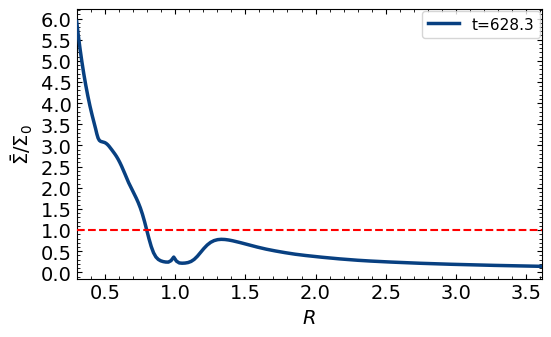

In [106]:
## Plot density, v_r, and Mdot

fig,axs = plt.subplots(1,1, figsize=(6,3.5),sharex=True,sharey=False)

#### Read in domain ####
d_rad = Rs[1] - Rs[0]
d_phi = phis[1] - phis[0]
rad_3d, phi_3d = np.meshgrid(Rs, phis, indexing='ij')

## \bar(Sigma) = azimuthally-averaged Sigma/"den", or
## \bar(Sigma)(R') = (1/2pi) * \int Sigma(R=R',phi) dphi
Sigma_integrand = den*d_phi
Sigma_avg = np.sum(Sigma_integrand[:,2:-2],axis=1)/(2*np.pi)

## Mdot(R) = mass inflow rate, or:
## Mdot(R') = \int Sigma(R=R',phi)*v_R(R',phi) (R*dphi)
Mdot_integrand = den*vR*rad_3d*d_phi
Mdot = np.sum(Mdot_integrand[:,2:-2],axis=1)

## mass-weighted v_R = Mdot / (2pi*R*\bar{Sigma}(R))
vr = Mdot / (2*np.pi*Rs*Sigma_avg)

#### Plot
zorder = 0
kws = {'c': '#084081', 'lw': 2.5, 'label': 't={:.1f}'.format(t_sim), 'zorder': zorder + 100}
Sigma_sol = Sigma0*Rs**(-1.5) # Sigma_avg[-1] * (Rs/Rs[-1])**-1.5
axs.plot(Rs,Sigma_avg/Sigma0,**kws)
#axs.plot(Rs,Sigma_avg/Sigma_sol,**kws)
#axs.loglog(rad_app,Sigma_avg,**kws)
     
#### Add Sigma=1
kws_theory = {'c': 'r', 'lw': 1.5, 'ls': '--', 'zorder': zorder+200}
axs.plot(Rs,Sigma_sol/Sigma_sol,**kws_theory)
axs.plot([],[],c='r',lw=1.5,ls='--',zorder=zorder+200)#,label='steady-state')

#### set axes
axs.set_xlabel(r'$R$')
axs.set_xlim(Rs[[0,-1]])
axs.set_ylabel(r'$\bar{\Sigma}/\Sigma_0$')
#axs.set_ylim(0., 1.65)
axs.tick_params(axis='both', which='both', direction='in', top=True, right=True)

axs.xaxis.set_major_locator(MultipleLocator(0.5))
axs.xaxis.set_major_formatter('{x:.1f}')
axs.xaxis.set_minor_locator(MultipleLocator(0.1))
axs.yaxis.set_major_locator(MultipleLocator(0.5))
axs.yaxis.set_major_formatter('{x:.1f}')
axs.yaxis.set_minor_locator(MultipleLocator(0.1))

axs.legend(
    fontsize=11,
    loc='upper right',        
    #bbox_to_anchor=(0.15, 1.22, 1.02, .452), 
    ncol=2,                  
    #mode="expand",          
    borderaxespad=0.1       
)